# Project flow 
    1. Problem Statement 
    2. Import libraries 
    3. Load Dataset 
    4. Data inspection 
    5. Data Cleaning
    6.Missing Value Analysis
    7. EDA 
        7.1 Univaraite analysis
        7.2 Bivariate analysis
        7.3 Multivariate Analysis
    8. Outliers Detection 
    9. Corr analysis
    10. Feature selection 
    11. Feature engineering -------------
    12. Encoding Categorical Variable----------------
    13.Train_test_split
    14. Feature scaling 
    15. Model Building 
    16. Model prediction 
    17.Model evaluation 
    18. Graph check prediction vs actual
    19. Error analysis
    20. Save model 
    21. Predict new house price

# Problem Statement :
    Obj :
        Build a Linear Regression Model That predict the selling price of a house using property realted features 

In [4]:
# 2 Import all Imp libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#######################################################
from sklearn.model_selection import train_test_split
####################################################
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
######################################################
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
import warnings
warnings.filterwarnings('ignore')

In [5]:
# load Dataset 
df=pd.read_csv('train.csv',index_col='Id')
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [7]:
for i in dict(df.isna().sum()).items():
    if i[1]>0:
        print(i[0],i[1])      

LotFrontage 259
Alley 1369
MasVnrType 872
MasVnrArea 8
BsmtQual 37
BsmtCond 37
BsmtExposure 38
BsmtFinType1 37
BsmtFinType2 38
Electrical 1
FireplaceQu 690
GarageType 81
GarageYrBlt 81
GarageFinish 81
GarageQual 81
GarageCond 81
PoolQC 1453
Fence 1179
MiscFeature 1406


In [8]:
# Seperating Numerical and categorical Columns
numerical_columns=df.select_dtypes(
    include= ['int64','float64']
).columns
print(f'numerical_columns = {numerical_columns}')
#################################################
categorical_columns=df.select_dtypes(
    include=['object']
).columns
print(f'Categorical Columns ={categorical_columns}')

numerical_columns = Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
Categorical Columns =Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [10]:
# Missing Value analysis 
missing =df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [11]:
missing_pct=(df.isnull().sum()/len(df)*100)
missing_pct=missing_pct[missing_pct>0].sort_values(ascending=False)
missing_pct

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

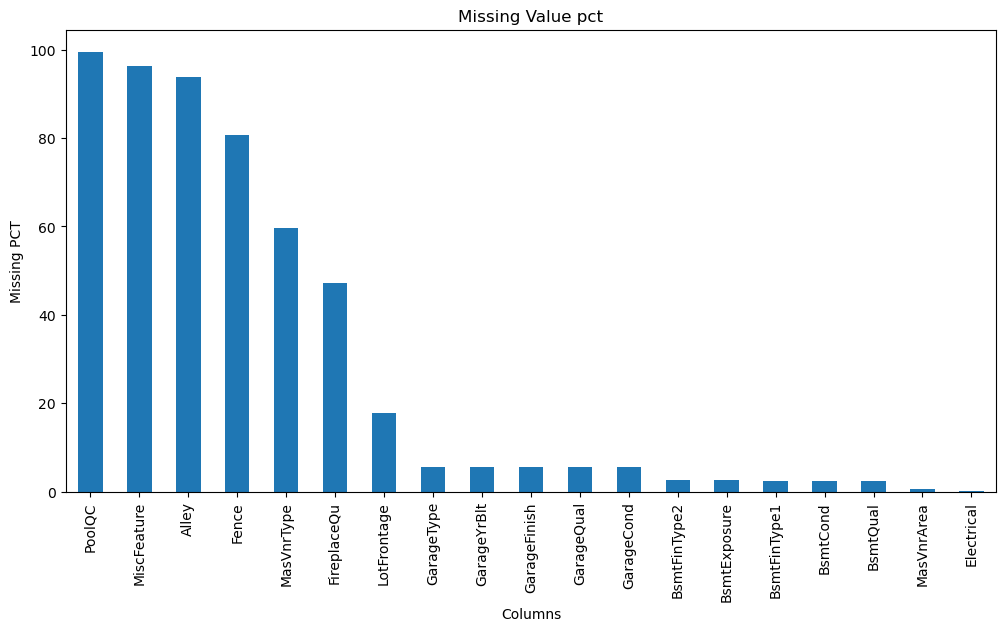

In [12]:
plt.figure(figsize=(12,6))
missing_pct.plot(kind='bar')
plt.title('Missing Value pct')
plt.xlabel('Columns')
plt.ylabel('Missing PCT')
plt.show()

In [13]:
# Target Variable Analysis
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

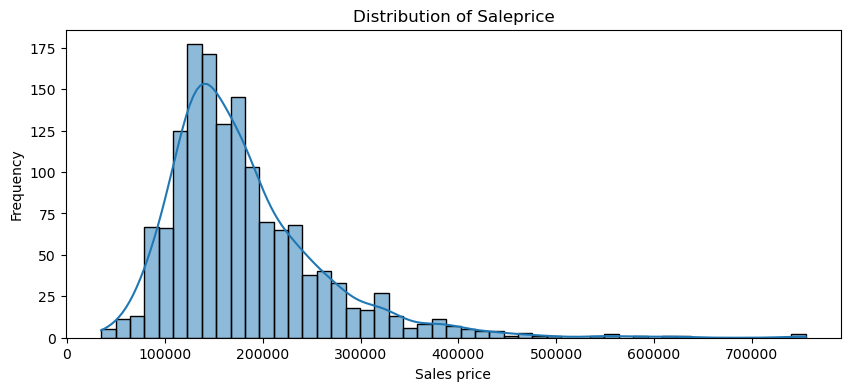

In [14]:
plt.figure(figsize=(10,4))
sns.histplot(
    df['SalePrice'],
    kde=True
)
plt.title('Distribution of Saleprice')
plt.xlabel('Sales price')
plt.ylabel('Frequency')
plt.show()

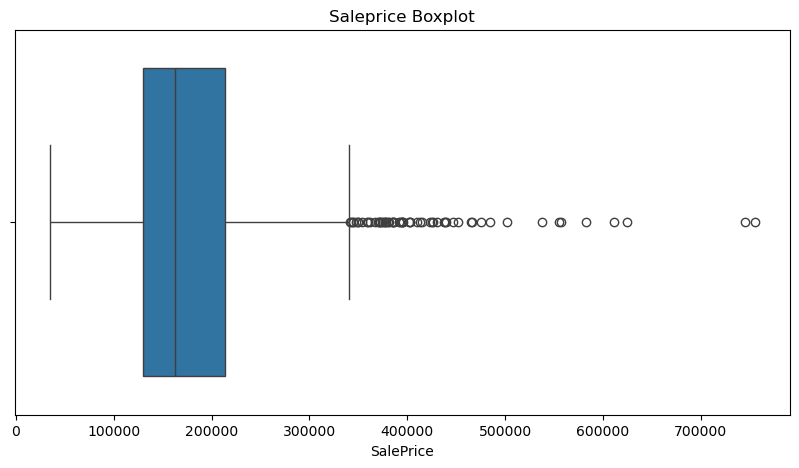

In [15]:
# Boxplot 
plt.figure(figsize=(10,5))
sns.boxplot(x=df['SalePrice'])
plt.title('Saleprice Boxplot')
plt.show()

# 7. EDA 
    7.1 Univaraite analysis
    7.2 Bivariate analysis
    7.3 Multivariate Analysis

### Univariate Analysis :
    Univaraite Analysis means studying one Variable at a Time 


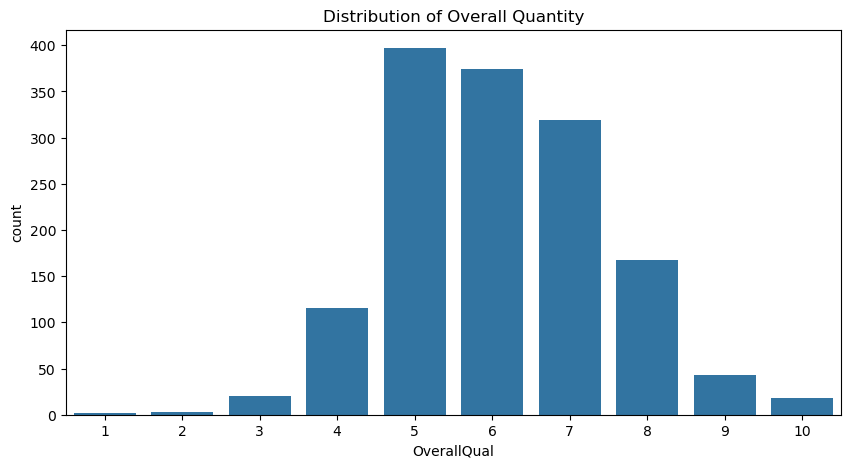

In [16]:
# Overall Distribution 
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='OverallQual'
)
plt.title('Distribution of Overall Quantity')
plt.show()

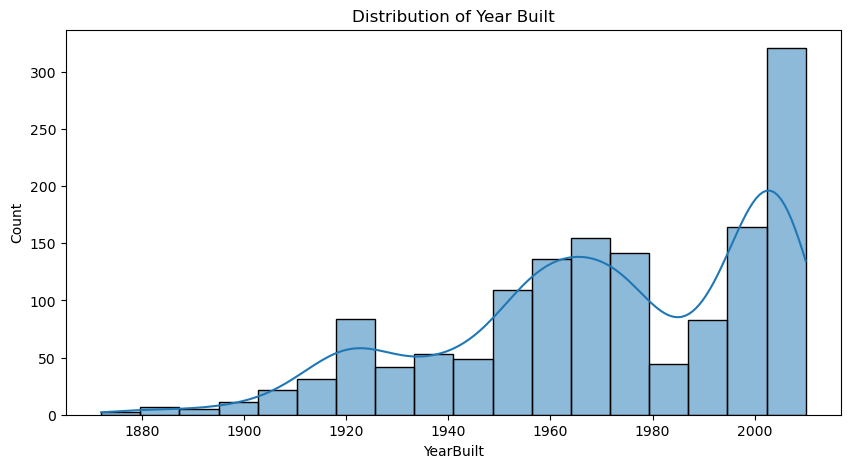

In [17]:
# Living area 
plt.figure(figsize=(10,5))
sns.histplot(
    df['YearBuilt'],
    kde=True
)
plt.title('Distribution of Year Built')
plt.show()

# Bivaraiate Analysis :
    Bivariate Analysis means studying the relationship between two Variables


In [18]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

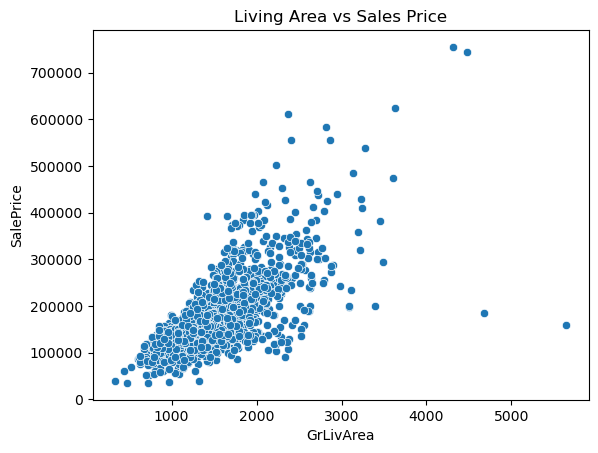

In [19]:
sns.scatterplot(data=df,x=df['GrLivArea'],y=df['SalePrice'])
plt.title('Living Area vs Sales Price')
plt.show() # Generally as Living area Incraese house price tends to incraese

# Multvariate Analysis 


In [20]:
selected_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "GarageArea"
]

In [21]:
corr_matrix = df[selected_features].corr()
corr_matrix

,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt,FullBath,BedroomAbvGr,TotRmsAbvGrd,GarageArea
SalePrice,1.000000,0.790982,0.708624,0.640409,0.613581,0.605852,0.522897,0.560664,0.168213,0.533723,0.623431
OverallQual,0.790982,1.000000,0.593007,0.600671,0.537808,0.476224,0.572323,0.550600,0.101676,0.427452,0.562022
GrLivArea,0.708624,0.593007,1.000000,0.467247,0.454868,0.566024,0.199010,0.630012,0.521270,0.825489,0.468997
GarageCars,0.640409,0.600671,0.467247,1.000000,0.434585,0.439317,0.537850,0.469672,0.086106,0.362289,0.882475
TotalBsmtSF,0.613581,0.537808,0.454868,0.434585,1.000000,0.819530,0.391452,0.323722,0.050450,0.285573,0.486665
1stFlrSF,0.605852,0.476224,0.566024,0.439317,0.819530,1.000000,0.281986,0.380637,0.127401,0.409516,0.489782
YearBuilt,0.522897,0.572323,0.199010,0.537850,0.391452,0.281986,1.000000,0.468271,-0.070651,0.095589,0.478954
FullBath,0.560664,0.550600,0.630012,0.469672,0.323722,0.380637,0.468271,1.000000,0.363252,0.554784,0.405656
BedroomAbvGr,0.168213,0.101676,0.521270,0.086106,0.050450,0.127401,-0.070651,0.363252,1.000000,0.676620,0.065253
TotRmsAbvGrd,0.533723,0.427452,0.825489,0.362289,0.285573,0.409516,0.095589,0.554784,0.676620,1.000000,0.337822


<Axes: >

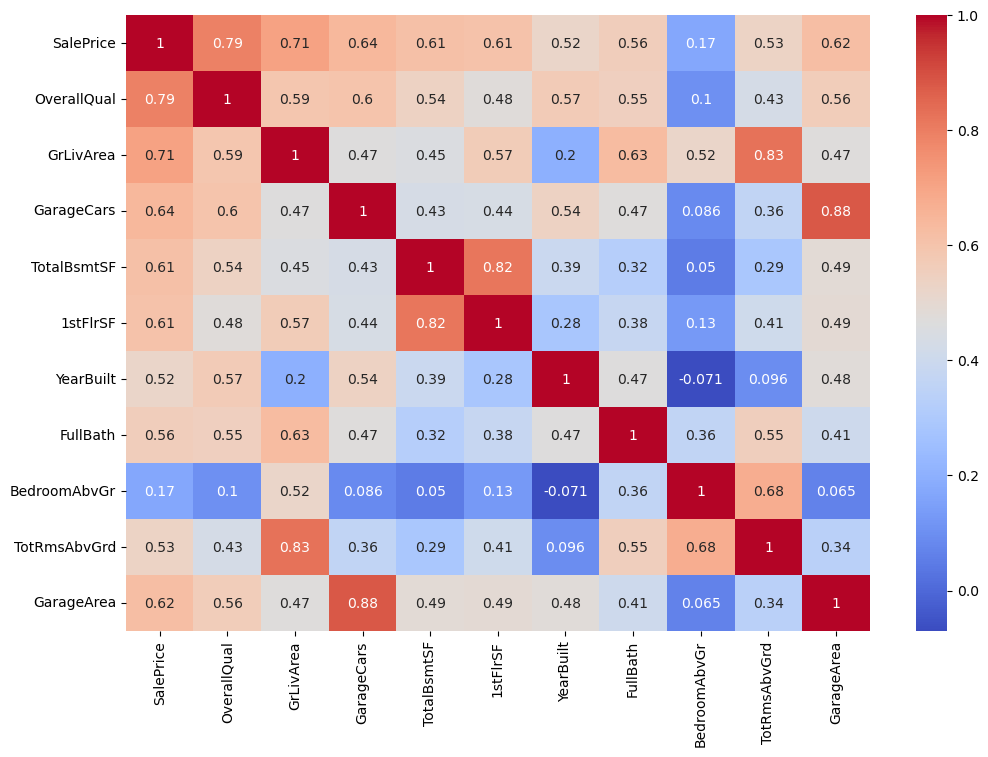

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

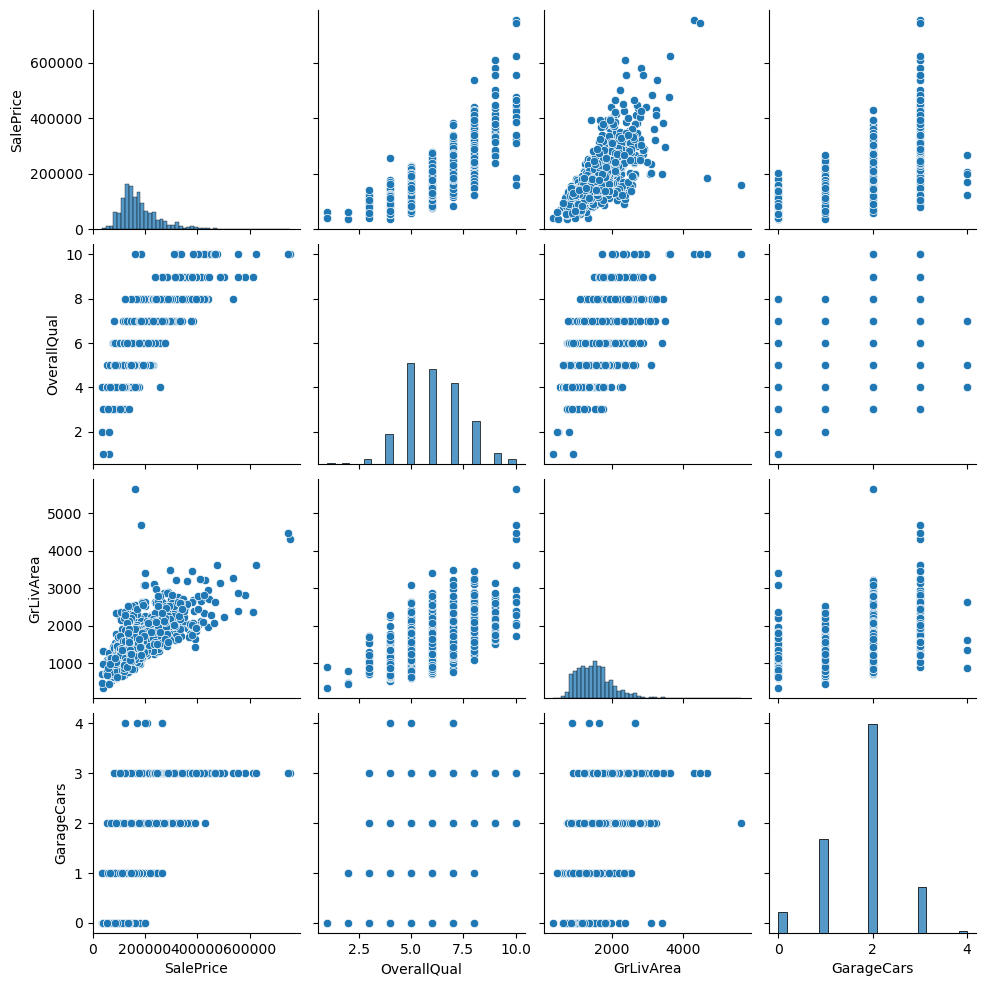

In [24]:
sns.pairplot(df[
             [
            "SalePrice",
        "OverallQual",
        "GrLivArea",
        "GarageCars"
             ]
])
plt.show()

In [25]:
# Identify Highly Correlated Features 
corr_with_target= (
    df.corr(numeric_only=True)['SalePrice'].
    sort_values(ascending=False)
)
corr_with_target.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [26]:
# Feature selection 
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr",
    "TotRmsAbvGrd",
    "GarageArea"
]
x = df[features]
y = df["SalePrice"]


In [27]:
# Missing check 
x.isna().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
GarageArea      0
dtype: int64

In [28]:
# Train_test Split :
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
print('x_train = ',x_train.shape)
print('y_train = ',y_train.shape)
print('x_test = ',x_test.shape)
print('y_test = ',y_test.shape)

x_train =  (1168, 10)
y_train =  (1168,)
x_test =  (292, 10)
y_test =  (292,)


In [30]:
# Feature scaling 
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [31]:
# Model Build
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Y=Mn*Xn +C
# Model coefficents
coefficeint=pd.DataFrame(
    {'Features':features,
    'Coefficient' : model.coef_
    })
print('Slope/weigth of each input features =\n',coefficeint)
print('intercept/ Bias of model is ',model.intercept_)

Slope/weigth of each input features =
        Features   Coefficient
0   OverallQual  27033.061741
1     GrLivArea  26006.506943
2    GarageCars   8202.129179
3   TotalBsmtSF   6957.377144
4      1stFlrSF   4307.086117
5     YearBuilt  11027.679572
6      FullBath  -2270.521017
7  BedroomAbvGr  -6839.246748
8  TotRmsAbvGrd   5400.722065
9    GarageArea   2514.019943
intercept/ Bias of model is  181441.54195205483


In [33]:
######### testing evaluation
# Prediction 
y_pred=model.predict(
    x_test
)
# Model evaluation
mae=mean_absolute_error(y_test,y_pred)
print(mae)
acc= r2_score(y_test,y_pred)
print(acc)

24767.431867529187
0.8033827424395268


In [34]:
######### Training evaluation
# Prediction 
y_pred_train=model.predict(
    x_train
)
# Model evaluation
mae=mean_absolute_error(y_train,y_pred_train)
print(mae)
acc= r2_score(y_train,y_pred_train)
print(acc)

23845.01607326287
0.7643134046743888


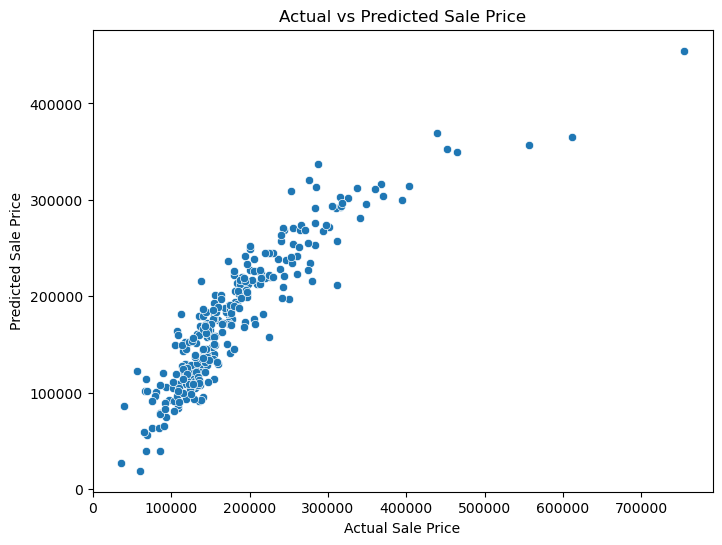

In [35]:
# Actual vs prediucted graph 
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=y_test,
    y=y_pred
)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.show()

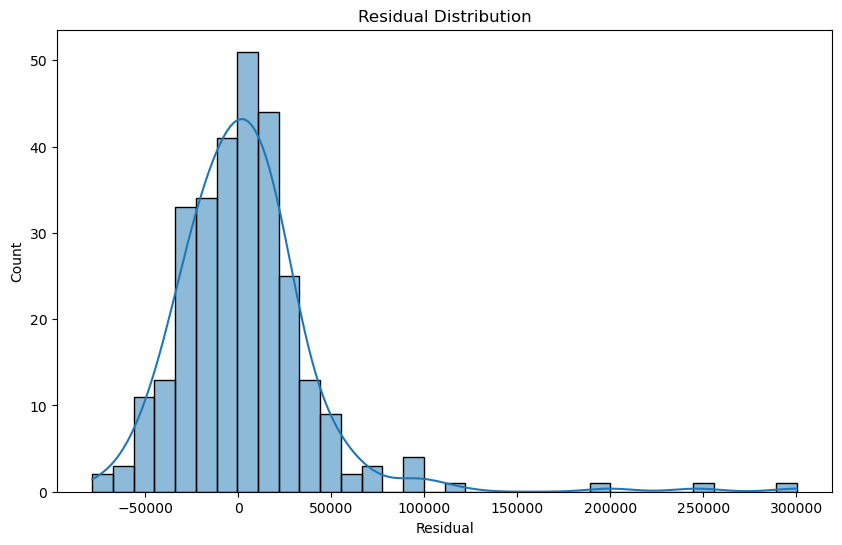

In [36]:
# 19. Error analysis
residual= y_test-y_pred
plt.figure(figsize=(10, 6))
sns.histplot(
    residual,
    kde=True
)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

In [37]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
############## Deploy  This Model 
from sklearn.impute import KNNImputer
import gradio as gr
import pandas as pd
def predict_house_price(
    OverallQual,
    GrLivArea,
    GarageCars,
    TotalBsmtSF,
    FirstFlrSF,
    YearBuilt,
    FullBath,
    BedroomAbvGr,
    TotRmsAbvGrd,
    GarageArea,
):
  new_house = pd.DataFrame({
      "OverallQual": [OverallQual],
      "GrLivArea": [GrLivArea],
      "GarageCars": [GarageCars],
      "TotalBsmtSF": [TotalBsmtSF],
      "1stFlrSF": [FirstFlrSF],
      "YearBuilt": [YearBuilt],
      "FullBath": [FullBath],
      "BedroomAbvGr": [BedroomAbvGr],
      "TotRmsAbvGrd": [TotRmsAbvGrd],
      "GarageArea": [GarageArea],
  })

  # Scale the new sample using your fitted scaler instance
  new_house_scaled = scaler.transform(new_house)

  # Prediction
  prediction = model.predict(new_house_scaled)
  return f"Predicted House Price: ₹ {prediction[0]:,.2f}"

In [39]:
from sklearn.impute import KNNImputer
import gradio as gr
interface = gr.Interface(
    fn=predict_house_price,
    inputs=[
        gr.Number(label="Overall Quality", value=7),
        gr.Number(label="Living Area (sq ft)", value=1800),
        gr.Number(label="Garage Cars", value=2),
        gr.Number(label="Total Basement Area (sq ft)", value=1000),
        gr.Number(label="First Floor Area (sq ft)", value=1000),
        gr.Number(label="Year Built", value=2005),
        gr.Number(label="Full Bathrooms", value=2),
        gr.Number(label="Bedrooms Above Ground", value=3),
        gr.Number(label="Total Rooms Above Ground", value=7),
        gr.Number(label="Garage Area (sq ft)", value=500),
    ],
    outputs=gr.Textbox(label="Predicted House Price"),
    title="🏠 House Price Prediction",
    description="Linear Regression model for predicting house sale price."
)


In [40]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
